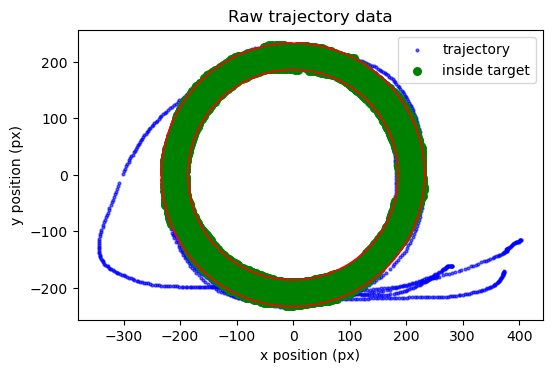

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# FILE PATHS
# ====================================================

RAW_FILE    = "../data/001MoDe_R1.csv" #continuous mouse trajectory
MARKER_FILE = "../data/001MoDe_R1.marker.csv" #event timestamps (DoRecord / DoPause)

# ====================================================
# PARSING METADATA FROM FIRST LINE OF RAW FILE
# ====================================================
with open(RAW_FILE, "r") as f:
    metadata_line = f.readline().strip()

# Metadata is written as "key value;key value;..."
metadata_entries = metadata_line.split(";")

# Initialize fields
center_x = 0.0
center_y = 0.0
radius_inner = 0.0
radius_outer = 0.0

# Extract numeric values from metadata
for entry in metadata_entries:
    tokens = entry.split()
    if len(tokens) != 2:
        continue
    key, val = tokens
    if key == "centerX":
        center_x = float(val)
    elif key == "centerY":
        center_y = float(val)
    elif key == "internalRadius":
        radius_inner = float(val)
    elif key == "externalRadius":
        radius_outer = float(val)

# important ! If numeries values are hardcoded (eg, "center_x = 552") 
# it won't carry over if another file w/ different metadata is used.

#importing the radius and tolerance for later use
task_radius = 0.0
task_tolerance = 0.0

for entry in metadata_entries: #same as before, taking them directly from the metadata
    tokens = entry.split()
    if len(tokens) != 2:
        continue
    key, val = tokens
    if key == "taskRadius":
        task_radius = float(val)
    elif key == "taskTolerance":
        task_tolerance = float(val)


# ====================================================
# PARSE EVENT MARKERS (DoRecord / DoPause)
# ====================================================
record_starts = []
record_stops  = []

with open(MARKER_FILE, "r") as f:
    for line in f:
        if "," not in line:
            continue
        
        parts = line.strip().split(",") # e.g., ["#Marker", "123456", "DoRecord"]
        if len(parts) < 3: 
            continue
        
        # parts[1] = timestamp, we keep only pure integers
        ts_str = parts[1]
        if not ts_str.isdigit():
            continue
        
        timestamp = int(ts_str) # in milliseconds
        event     = parts[2] # e.g., "DoRecord" or "DoPause"
        
        if "DoRecord" in event:
            record_starts.append(timestamp)
        elif "DoPause" in event:
            record_stops.append(timestamp)

record_starts = np.array(record_starts)
record_stops  = np.array(record_stops)

# ====================================================
# LOAD TRAJECTORY DATA 
# ====================================================
# Line structure after skip:
# time, mouseX, mouseY, inTargetFlag
raw_data = np.genfromtxt(RAW_FILE, delimiter=",", skip_header=4) #skip the metadata + 3 header lines
time_all, mouse_x_all, mouse_y_all, inside_target_all = raw_data.T

# Recenter into target coordinate system
x_all = mouse_x_all - center_x
y_all = -(mouse_y_all - center_y)  # flip Y-axis, otherwise upside-down

# ====================================================
# KEEP ONLY VALID RECORDING SEGMENTS
# ====================================================
# manually adjusting the mask is needed - some corrupted timestamps slept throught ( "0.0.0.0.0")
timestamp_valid = time_all > 1e12 #keep only valid timestamps (> 1 trillion ms, since it's that unix epoch time in seconds)

valid_mask = np.zeros_like(time_all, dtype=bool) #build the mask from DoRecord / DoPause events

for start, stop in zip(record_starts, record_stops):
    valid_mask |= (time_all >= (start - 30)) & (time_all <= stop)

# combine the masks
valid_mask &= timestamp_valid

#apply the final mask
x_valid = x_all[valid_mask] #filtered x positions
y_valid = y_all[valid_mask] #filtered y positions
t_valid = time_all[valid_mask] #filtered timestamps


# ====================================================
# PLOT TRAJECTORY + DONUT
# ====================================================
plt.figure(figsize=(6, 6))

inside_mask_full = inside_target_all.astype(bool)    # full-length mask BEFORE slicing
inside_mask_valid = inside_mask_full[valid_mask]     # mask aligned with x_valid, y_valid

# compute radii only for inside-target samples
r_inside = np.sqrt(x_valid[inside_mask_valid]**2 + y_valid[inside_mask_valid]**2)

# Compute empirical radii
inner_r = r_inside.min()
outer_r = r_inside.max()

theta = np.linspace(0, 2*np.pi, 512)
circle_inner_x = inner_r * np.cos(theta)
circle_inner_y = inner_r * np.sin(theta)
circle_outer_x = outer_r * np.cos(theta)
circle_outer_y = outer_r * np.sin(theta)

inside_mask = inside_mask_valid        # rename consistently
outside_mask = ~inside_mask


# Outside trajectory)

plt.scatter(
    x_valid[outside_mask],
    y_valid[outside_mask],
    s=4,
    color="blue",
    alpha=0.6,
    label="trajectory"
)


# Inside target (green dots)

plt.scatter(
    x_valid[inside_mask],
    y_valid[inside_mask],
    s=30,
    color="green",
    label="inside target"
)


# 3) red annulus (the inner and outer red circles, has to be on top)

plt.plot(circle_inner_x, circle_inner_y, color="red", linewidth=1.2, zorder=4)
plt.plot(circle_outer_x, circle_outer_y, color="red", linewidth=1.2, zorder=4)

plt.gca().set_aspect("equal")
plt.xlabel("x position (px)")
plt.ylabel("y position (px)")
plt.title("Raw trajectory data")
plt.legend()
plt.show()



# ====================================================
# TODO
# ====================================================
# fix plotting --> inside line & legends / fix name confusion w/ previous itterations
